In [2]:
# 아이리스 꽃받침 데이터에서 길이값과 너비값을 활용하여 군집화 수행 

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("./data/iris_sepal.csv")

In [5]:
df

,Sepal.length,Sepal.width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


Text(29.000000000000007, 0.5, 'Sepal.width')

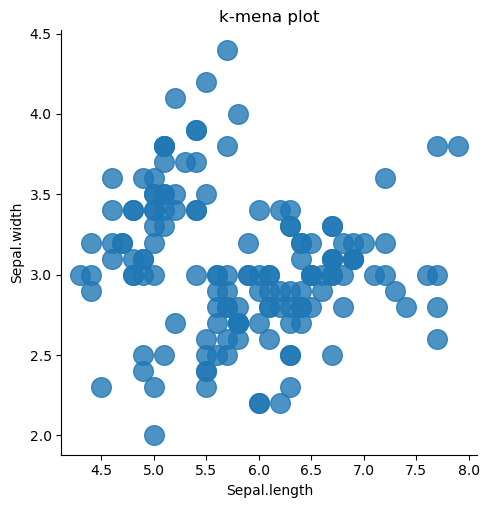

In [6]:
# 산점도 그리기

sns.lmplot(x='Sepal.length', y='Sepal.width', data=df, fit_reg=False, scatter_kws={"s":200})

plt.title('k-mena plot')
plt.xlabel('Sepal.length')
plt.ylabel('Sepal.width')

In [7]:
!pip install threadpoolctl==3.1.0

C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

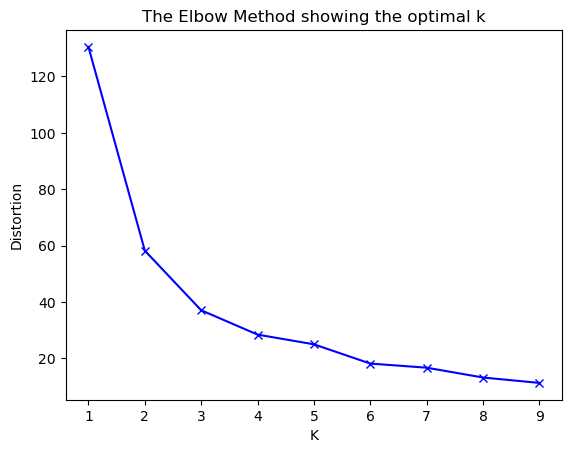

In [8]:
X = df.values # 인덱스를 제외한 값을 ndarray로 추출
inertia_arr = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0).fit(X) #모델 적합
    inertia = kmeanModel.inertia_
    inertia_arr.append(inertia)

# Plot the elbow
plt.plot(K, inertia_arr, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [17]:
# 적정 클러스터 수 계산
# k=3으로 클러스터링

# 최적 k 개수로 클러스터링 수행
kmeans = KMeans(n_clusters = 3)
kmeans.fit(X)

C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [19]:
kmeans.labels_ # 클러스터 결과 확인

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0])

In [21]:
df['cluster_id'] = kmeans.labels_

In [23]:
df

,Sepal.length,Sepal.width,cluster_id
0,5.1,3.5,2
1,4.9,3.0,2
2,4.7,3.2,2
3,4.6,3.1,2
4,5.0,3.6,2
...,...,...,...
145,6.7,3.0,1
146,6.3,2.5,0
147,6.5,3.0,1
148,6.2,3.4,1


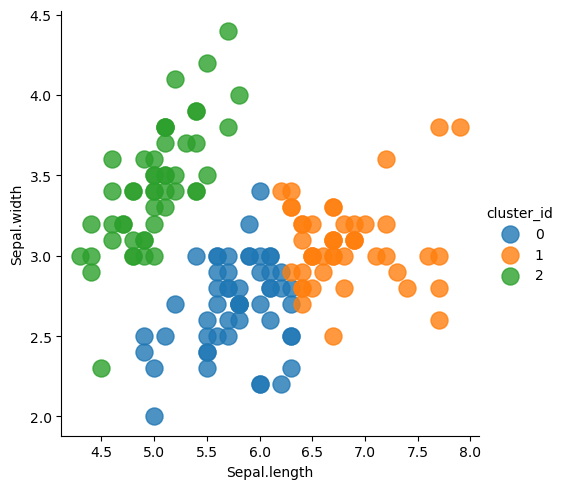

In [25]:
# 클러스터링 시각화
sns.lmplot(x='Sepal.length', y='Sepal.width', data=df, fit_reg=False, scatter_kws={"s":150}, hue='cluster_id')

In [27]:
#60211356 장유진